# ASL Merged Dataset - Exploratory Data Analysis

Covers:
1. Class distribution in `merged_dataset/`
2. Split distribution (train / val / test) — run `prepare_data.py` first
3. Image statistics (dimensions, brightness, channel means)
4. Normalisation statistics from `norm_stats.json`
5. Per-class sample grids
6. Class weights for imbalance-aware loss

In [1]:
import sys, pathlib, json
sys.path.insert(0, str(pathlib.Path('.').resolve().parent / 'src'))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.notebook import tqdm

from config import load_config

cfg = load_config('../configs/config.yaml')
MERGED = pathlib.Path('..') / cfg.merged_dir
SPLITS = pathlib.Path('..') / cfg.splits_dir
DATA_ROOT = pathlib.Path('..') / cfg.data_root

print(f'Environment : {cfg.env}')
print(f'Merged dir  : {MERGED}')
print(f'Classes     : {len(cfg.classes)}  →  {cfg.classes}')
print(f'Norm mean   : {cfg.norm_mean}  (dataset={cfg.norm_stats_from_dataset})')
print(f'Norm std    : {cfg.norm_std}')

[config] environment: local
[config] norm_stats.json not found — using ImageNet fallback. Run prepare_data.py to generate dataset-specific stats.
Environment : local
Merged dir  : ..\data\merged_dataset
Classes     : 37  →  ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'blank']
Norm mean   : (0.485, 0.456, 0.406)  (dataset=False)
Norm std    : (0.229, 0.224, 0.225)


## 1. Class distribution in `merged_dataset/`

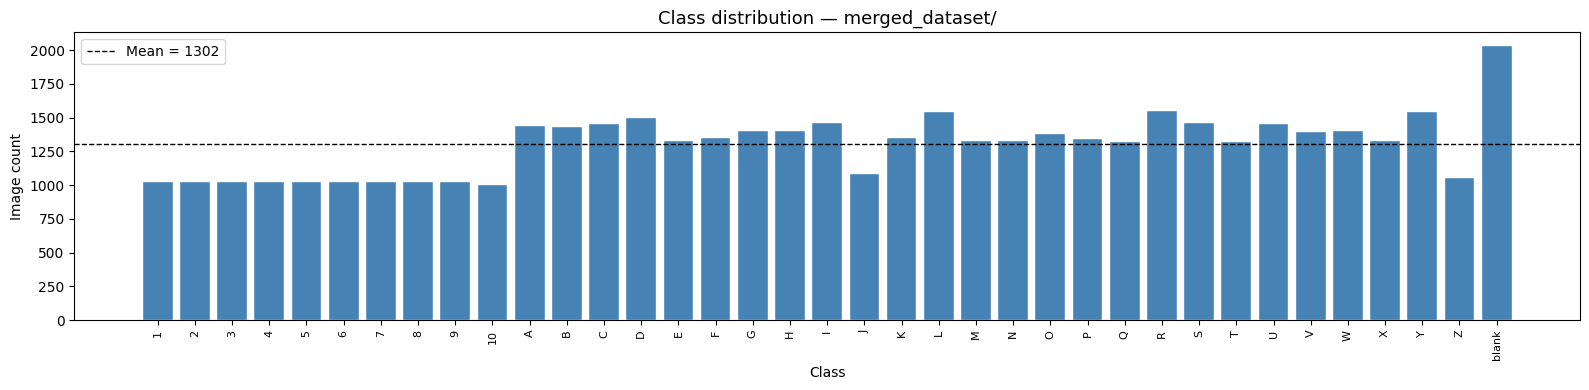

Total images : 48,183
Classes      : 37
Imbalance    : 2.0x  (blank = 2,031  vs  10 = 1,000)


In [2]:
IMAGE_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

counts = {}
if not MERGED.exists():
    print('merged_dataset/ not found. Run scripts/merge_datasets.py first.')
else:
    for cls_dir in sorted(MERGED.iterdir()):
        if cls_dir.is_dir():
            n = sum(1 for f in cls_dir.iterdir() if f.suffix.lower() in IMAGE_EXTS)
            counts[cls_dir.name] = n

    counts_s = pd.Series(counts).reindex(cfg.classes, fill_value=0)

    fig, ax = plt.subplots(figsize=(16, 4))
    bars = ax.bar(counts_s.index, counts_s.values, color='steelblue', edgecolor='white', linewidth=0.3)
    ax.axhline(counts_s.mean(), color='black', linestyle='--', linewidth=1,
               label=f'Mean = {counts_s.mean():.0f}')
    ax.set_title('Class distribution — merged_dataset/', fontsize=13)
    ax.set_xlabel('Class')
    ax.set_ylabel('Image count')
    ax.tick_params(axis='x', labelsize=8, rotation=90)
    ax.legend()
    plt.tight_layout()
    plt.show()

    print(f'Total images : {counts_s.sum():,}')
    print(f'Classes      : {(counts_s > 0).sum()}')
    print(f'Imbalance    : {counts_s.max() / max(counts_s[counts_s > 0].min(), 1):.1f}x  '
          f'({counts_s.idxmax()} = {counts_s.max():,}  vs  '
          f'{counts_s[counts_s > 0].idxmin()} = {counts_s[counts_s > 0].min():,})')

## 2. Split distribution (train / val / test)

Run `python -m src.prepare_data --skip_shards` first.

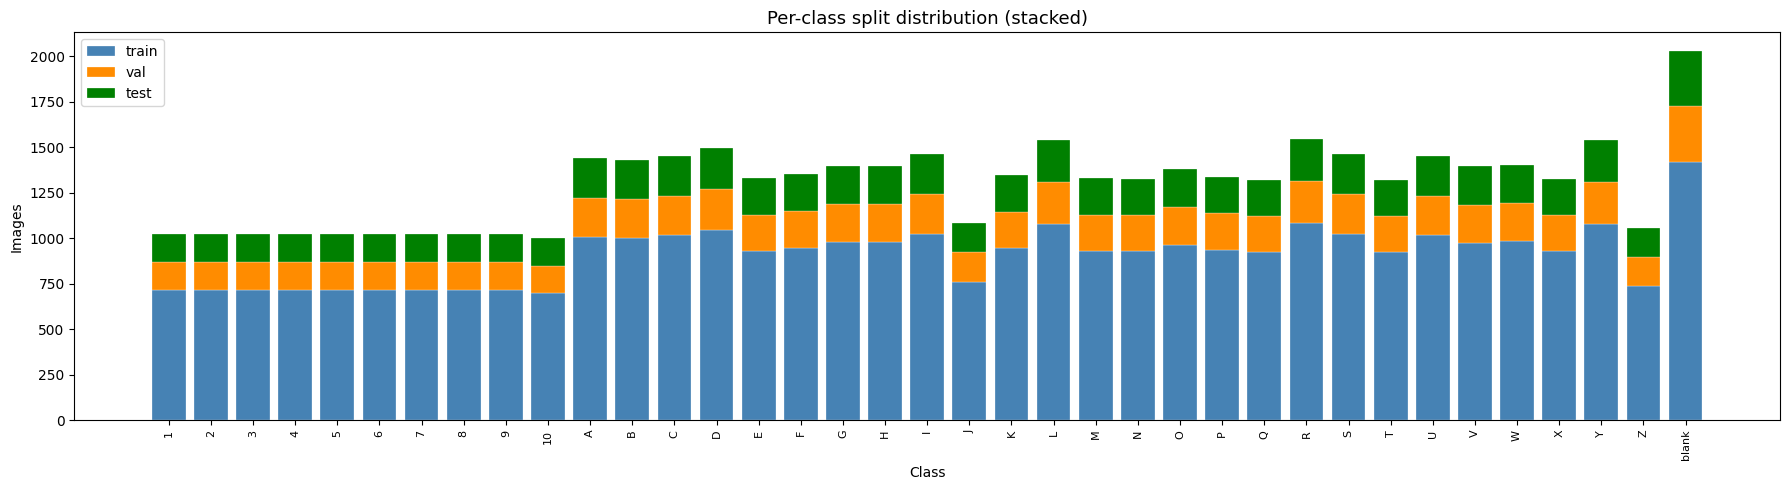

Split totals:
  train: 33,727  (70.0%)
  val  :  7,231  (15.0%)
  test :  7,225  (15.0%)


In [3]:
split_dfs = {}
for split in ('train', 'val', 'test'):
    p = SPLITS / f'{split}.csv'
    if p.exists():
        split_dfs[split] = pd.read_csv(p)
    else:
        print(f'  {p} not found — run prepare_data.py first')

if split_dfs:
    combined = pd.concat(
        [df.assign(split=s) for s, df in split_dfs.items()],
        ignore_index=True,
    )
    pivot = (
        combined.groupby(['class_name', 'split'])
        .size()
        .unstack(fill_value=0)
        .reindex(cfg.classes, fill_value=0)
    )

    colors = {'train': 'steelblue', 'val': 'darkorange', 'test': 'green'}
    fig, ax = plt.subplots(figsize=(18, 5))
    bottom = np.zeros(len(pivot))
    for split in ('train', 'val', 'test'):
        if split in pivot.columns:
            ax.bar(pivot.index, pivot[split].values, bottom=bottom,
                   label=split, color=colors[split], edgecolor='white', linewidth=0.2)
            bottom += pivot[split].values
    ax.set_title('Per-class split distribution (stacked)', fontsize=13)
    ax.set_xlabel('Class')
    ax.set_ylabel('Images')
    ax.tick_params(axis='x', labelsize=8, rotation=90)
    ax.legend()
    plt.tight_layout()
    plt.show()

    print('Split totals:')
    for s, df in split_dfs.items():
        pct = len(df) / len(combined) * 100
        print(f'  {s:5s}: {len(df):6,}  ({pct:.1f}%)')

## 3. Image statistics

Image stats:   0%|          | 0/2000 [00:00<?, ?it/s]

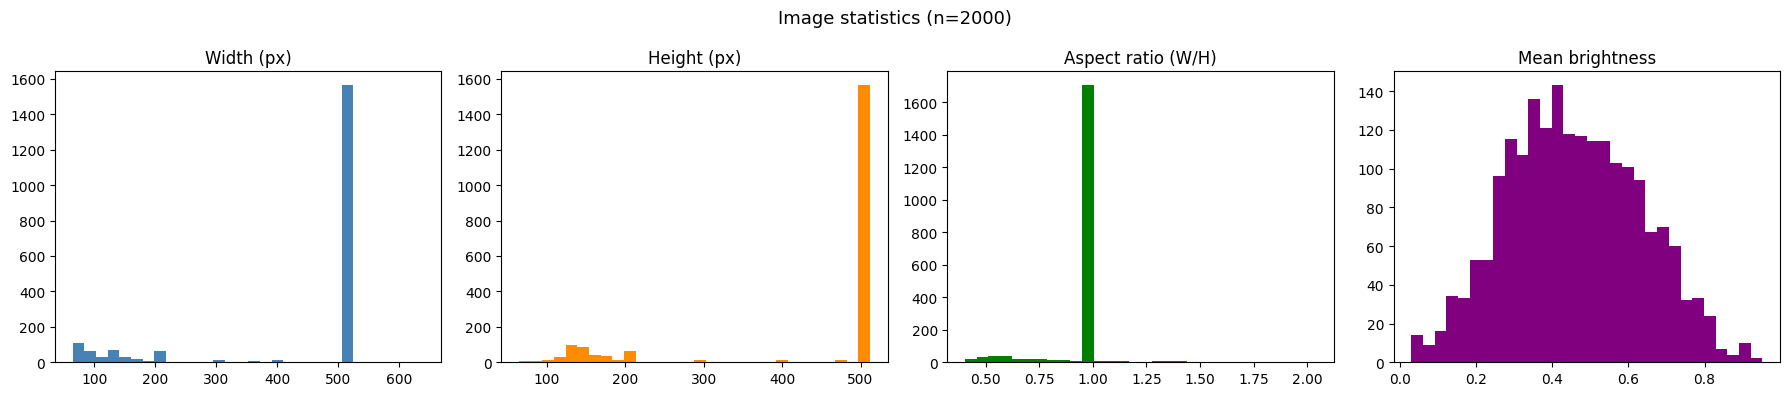

Width  : 433 ± 157 px
Height : 438 ± 144 px
Ch means (R/G/B): 0.491 / 0.456 / 0.422


In [4]:
SAMPLE_N = 2000

all_files = [
    f for cls_dir in MERGED.iterdir() if cls_dir.is_dir()
    for f in cls_dir.iterdir() if f.suffix.lower() in IMAGE_EXTS
]

rng = np.random.default_rng(42)
sample_files = rng.choice(all_files, size=min(SAMPLE_N, len(all_files)), replace=False)

widths, heights, aspects, brightnesses = [], [], [], []
ch_means = [[], [], []]

for path in tqdm(sample_files, desc='Image stats'):
    try:
        with Image.open(path) as img:
            w, h = img.size
            widths.append(w); heights.append(h); aspects.append(w / h)
            arr = np.array(img.convert('RGB'), dtype=np.float32) / 255.0
            brightnesses.append(arr.mean())
            for c in range(3):
                ch_means[c].append(arr[:, :, c].mean())
    except Exception:
        pass

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
axes[0].hist(widths,       bins=30, color='steelblue');   axes[0].set_title('Width (px)')
axes[1].hist(heights,      bins=30, color='darkorange');  axes[1].set_title('Height (px)')
axes[2].hist(aspects,      bins=30, color='green');       axes[2].set_title('Aspect ratio (W/H)')
axes[3].hist(brightnesses, bins=30, color='purple');      axes[3].set_title('Mean brightness')
plt.suptitle(f'Image statistics (n={len(widths)})', fontsize=13)
plt.tight_layout(); plt.show()

print(f'Width  : {np.mean(widths):.0f} ± {np.std(widths):.0f} px')
print(f'Height : {np.mean(heights):.0f} ± {np.std(heights):.0f} px')
print(f'Ch means (R/G/B): {np.mean(ch_means[0]):.3f} / {np.mean(ch_means[1]):.3f} / {np.mean(ch_means[2]):.3f}')

## 4. Normalisation statistics from `norm_stats.json`

Computed over 8,000 images  (401,408,000 pixels)
Image size used : 224px



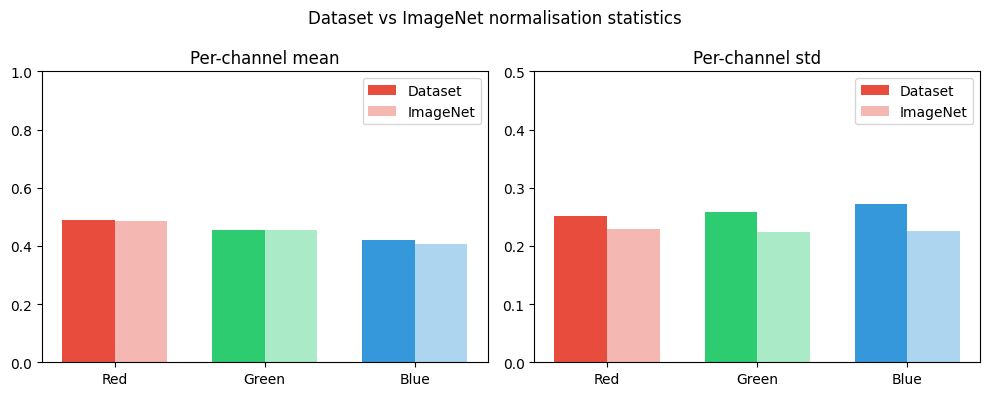

  Red  : mean=0.4876 (ImageNet 0.4850)  std=0.2514 (ImageNet 0.2290)
  Green: mean=0.4538 (ImageNet 0.4560)  std=0.2589 (ImageNet 0.2240)
  Blue : mean=0.4196 (ImageNet 0.4060)  std=0.2716 (ImageNet 0.2250)


In [5]:
norm_path = DATA_ROOT / 'norm_stats.json'
if not norm_path.exists():
    print('norm_stats.json not found. Run prepare_data.py first.')
else:
    stats = json.loads(norm_path.read_text())
    mean = stats['mean']
    std  = stats['std']
    print(f"Computed over {stats['n_samples']:,} images  ({stats['n_pixels']:,} pixels)")
    print(f"Image size used : {stats['image_size']}px")
    print()

    channels = ['Red', 'Green', 'Blue']
    imagenet_mean = [0.485, 0.456, 0.406]
    imagenet_std  = [0.229, 0.224, 0.225]

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    x = np.arange(3)
    w = 0.35
    axes[0].bar(x - w/2, mean,          w, label='Dataset', color=['#e74c3c','#2ecc71','#3498db'])
    axes[0].bar(x + w/2, imagenet_mean, w, label='ImageNet', color=['#e74c3c','#2ecc71','#3498db'], alpha=0.4)
    axes[0].set_xticks(x); axes[0].set_xticklabels(channels)
    axes[0].set_title('Per-channel mean'); axes[0].legend(); axes[0].set_ylim(0, 1)

    axes[1].bar(x - w/2, std,          w, label='Dataset', color=['#e74c3c','#2ecc71','#3498db'])
    axes[1].bar(x + w/2, imagenet_std, w, label='ImageNet', color=['#e74c3c','#2ecc71','#3498db'], alpha=0.4)
    axes[1].set_xticks(x); axes[1].set_xticklabels(channels)
    axes[1].set_title('Per-channel std'); axes[1].legend(); axes[1].set_ylim(0, 0.5)

    plt.suptitle('Dataset vs ImageNet normalisation statistics', fontsize=12)
    plt.tight_layout(); plt.show()

    for c, ch in enumerate(channels):
        print(f'  {ch:5s}: mean={mean[c]:.4f} (ImageNet {imagenet_mean[c]:.4f})  '
              f'std={std[c]:.4f} (ImageNet {imagenet_std[c]:.4f})')

## 5. Per-class sample grids

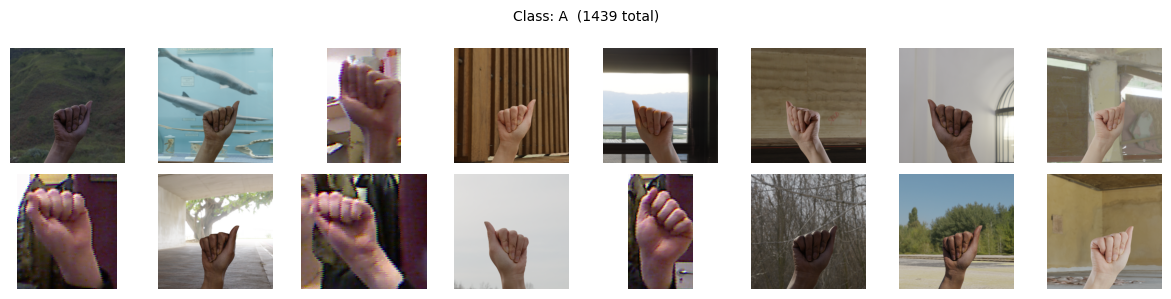

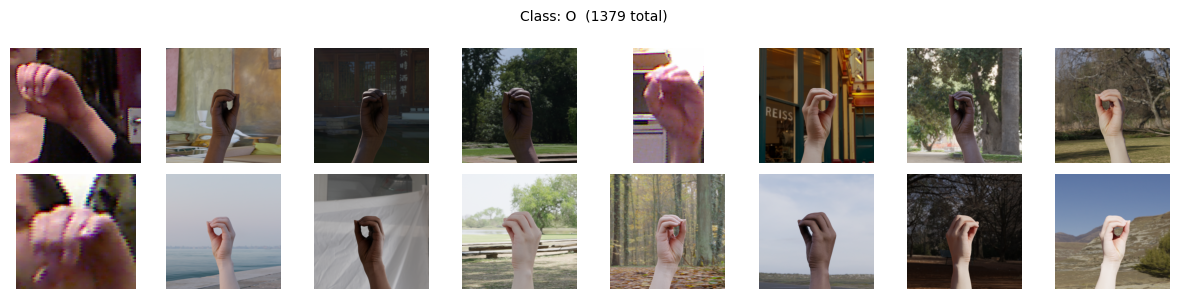

Class '0' not found in merged_dataset/


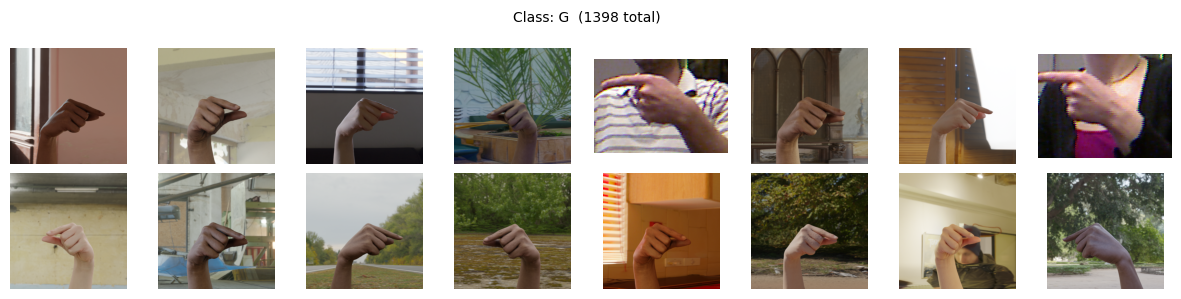

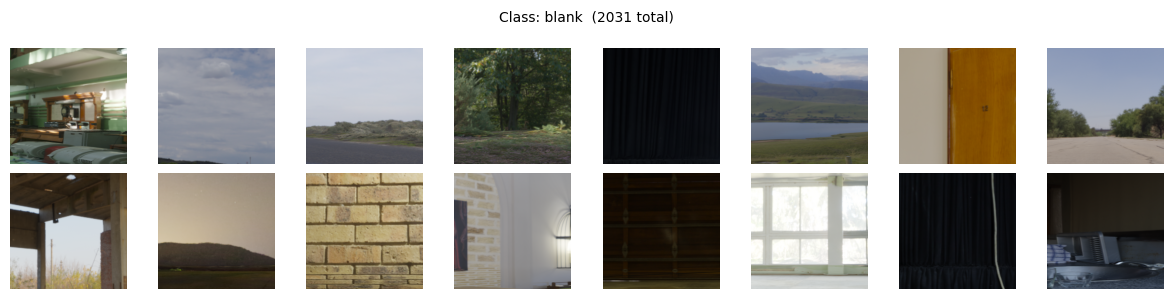

In [6]:
def show_class_grid(cls_name: str, n_cols: int = 8, n_rows: int = 2):
    cls_dir = MERGED / cls_name
    if not cls_dir.exists():
        print(f'Class {cls_name!r} not found in merged_dataset/')
        return
    files = [f for f in cls_dir.iterdir() if f.suffix.lower() in IMAGE_EXTS]
    sample = rng.choice(files, size=min(n_cols * n_rows, len(files)), replace=False)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 1.5, n_rows * 1.5))
    axes = axes.flatten()
    for ax, path in zip(axes, sample):
        try:
            ax.imshow(Image.open(path).convert('RGB'))
        except Exception:
            ax.text(0.5, 0.5, 'err', ha='center', va='center')
        ax.axis('off')
    for ax in axes[len(sample):]:
        ax.axis('off')
    fig.suptitle(f'Class: {cls_name}  ({len(files)} total)', fontsize=10)
    plt.tight_layout(); plt.show()

for cls in ['A', 'O', '0', 'G', 'blank']:
    show_class_grid(cls)

## 6. Class weights for imbalance-aware loss

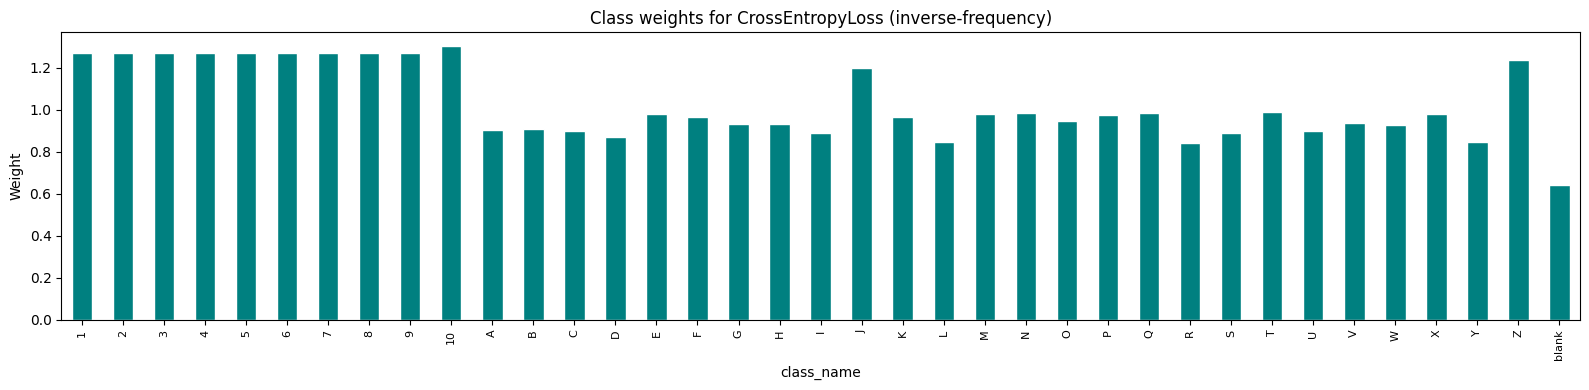

Train samples: 33,727
Class counts (sorted):
class_name
10        700.0
1         717.0
3         717.0
2         717.0
5         717.0
6         717.0
7         717.0
4         717.0
8         717.0
9         717.0
Z         738.0
J         760.0
T         923.0
Q         926.0
N         928.0
E         930.0
X         930.0
M         930.0
P         937.0
K         945.0
F         946.0
O         965.0
V         976.0
G         979.0
H         979.0
W         983.0
B        1003.0
A        1007.0
U        1016.0
C        1017.0
I        1024.0
S        1025.0
D        1046.0
L        1078.0
Y        1079.0
R        1082.0
blank    1422.0


In [7]:
train_csv = SPLITS / 'train.csv'
if not train_csv.exists():
    print('Run prepare_data.py first to generate splits.')
else:
    train_df = pd.read_csv(train_csv)
    counts_cls = (
        train_df.groupby('class_name').size()
        .reindex(cfg.classes, fill_value=1)
        .astype(float)
    )
    weights = counts_cls.sum() / (len(cfg.classes) * counts_cls)

    fig, ax = plt.subplots(figsize=(16, 4))
    weights.plot.bar(ax=ax, color='teal', edgecolor='white')
    ax.set_title('Class weights for CrossEntropyLoss (inverse-frequency)', fontsize=12)
    ax.set_ylabel('Weight')
    ax.tick_params(axis='x', labelsize=8, rotation=90)
    plt.tight_layout(); plt.show()

    print(f'Train samples: {len(train_df):,}')
    print(f'Class counts (sorted):')
    print(counts_cls.sort_values().to_string())